# 📊 RRT vs RRT*

В этом ноутбуке проводится сравнение RRT и RRT* на случайно генерируемых гауссовых полях.

## Описание проекта

### 🎯 Цель исследования

Сравнить RRT с RRT*

по следующим метрикам:

- время выполнения
- количество посещённых и обработанных узлов
- длина найденного пути (евклидова и пиксельная)
- успешность нахождения пути
- максимальные углы в пути (вбок и продольный)
- минимальные расстояния до препятсвия (евклидово и пиксельное)

### 🧪 Методология

Для каждого запуска:

1. Генерируется поле фиксированного размера (1000x1000) с гаусами с случайными параметрами в заданых диапозонах.
2. Метрики записываются в CSV файл.
3. Максимально допустимые углы вперед/назад и вбок = 30 градусам
4. Всего 100 запусков

#### 📌 Важно

Так как число гауссов и размер карты не менятеся в экспериментах, то их можно грубо сравнить сравнить по средним метрикам, но только если было большое число запусков.

### Задачи исследования

1. Загрузить библиотеки и таблицу
2. Небольшая очистка/подготовка данных
3. Базовая статистика
- Вывод
4. Парное сравнение
- Собрать парный датасет (RRT* vs RRT)
- В чем RRT* лучше RRT?
- Вывод

## Ход исследования

### 1) Загрузка библиотек и таблицы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# путь к CSV
path = "../var/metrics/rrt.csv"

df = pd.read_csv(path)

df.head()

,environment,algorithmName,executionTimeMs,pathNodes,expandedNodes,euclideanLength,pixelLength,pathFound,minObstacleDistance,minObstacleDistancePixel,maxSideAngle,maxUpDownAngle
0,continuous,RRT,26.03530,95,792,1845.32,1642,1,4,4,29.5119,25.2512
1,continuous,RRT*,3035.33000,89,25111,1485.78,1268,1,4,4,25.9998,13.5862
2,continuous,RRT,6.12486,88,199,1727.07,1491,1,4,4,29.8472,26.8503
3,continuous,RRT*,2985.16000,111,25105,1467.46,1205,1,4,4,28.1332,24.5349
4,continuous,RRT,64.92870,95,1648,1847.74,1614,1,2,2,29.6040,23.7951


In [2]:
continuous = df[df["environment"] == "continuous"]
success = (
    continuous.groupby("algorithmName")["pathFound"]
         .agg(["sum", "count", "mean"])
)

success["success_%"] = success["mean"] * 100
print(success)

               sum  count  mean  success_%
algorithmName                             
RRT             99    100  0.99       99.0
RRT*            93    100  0.93       93.0


### 2) Небольшая очистка/подготовка

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   environment               200 non-null    object 
 1   algorithmName             200 non-null    object 
 2   executionTimeMs           200 non-null    float64
 3   pathNodes                 200 non-null    int64  
 4   expandedNodes             200 non-null    int64  
 5   euclideanLength           200 non-null    float64
 6   pixelLength               200 non-null    int64  
 7   pathFound                 200 non-null    int64  
 8   minObstacleDistance       200 non-null    int64  
 9   minObstacleDistancePixel  200 non-null    int64  
 10  maxSideAngle              200 non-null    float64
 11  maxUpDownAngle            200 non-null    float64
dtypes: float64(4), int64(6), object(2)
memory usage: 18.9+ KB


In [4]:
# приводим типы (на всякий случай)
df["executionTimeMs"] = df["executionTimeMs"].astype(float)
df["expandedNodes"] = df["expandedNodes"].astype(int)
df["pathNodes"] = df["pathNodes"].astype(int)
df["pathFound"] = df["pathFound"].astype(int)

df["euclideanLength"] = df["euclideanLength"].astype(float)
df["pixelLength"] = df["pixelLength"].astype(int)

df["minObstacleDistance"] = df["minObstacleDistance"].astype(float)
df["minObstacleDistancePixel"] = df["minObstacleDistancePixel"].astype(int)
df["maxSideAngle"] = df["maxSideAngle"].astype(float)
df["maxUpDownAngle"] = df["maxUpDownAngle"].astype(float)

In [5]:
# разделяем по алгоритмам
rrt = continuous[continuous["algorithmName"] == "RRT"].reset_index(drop=True)
rrt_star = continuous[continuous["algorithmName"] == "RRT*"].reset_index(drop=True)

# проверяем что строки совпадают по run-логике
n = min(len(rrt), len(rrt_star))

rrt = rrt.iloc[:n]
rrt_star = rrt_star.iloc[:n]

In [6]:
mask = (
    (rrt["pathFound"] == 1) &
    (rrt_star["pathFound"] == 1)
)

rrt = rrt[mask].reset_index(drop=True)
rrt_star = rrt_star[mask].reset_index(drop=True)

In [7]:
continuous_ok = pd.concat([rrt, rrt_star], ignore_index=True)

### 3) Базовая статистика


=========== executionTimeMs ===========
                   mean    median      std       min      max
algorithmName                                                
RRT             138.843    26.873  533.527     5.593  4821.64
RRT*           2983.502  2981.740   25.435  2902.910  3053.88


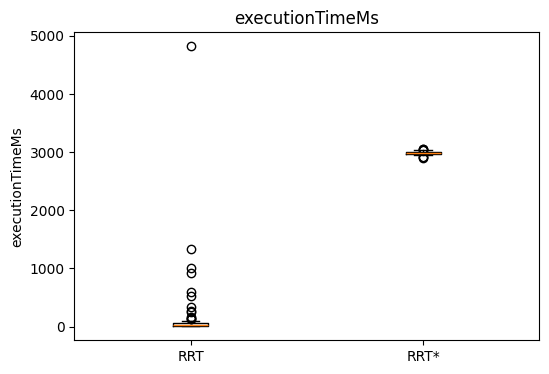


=========== expandedNodes ===========
                    mean   median       std    min    max
algorithmName                                            
RRT             1517.667    802.0  2446.902    184  17944
RRT*           24921.419  24918.0   171.410  24198  25359


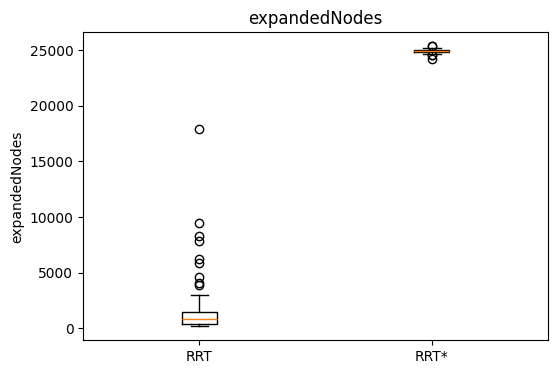


=========== pathNodes ===========
                  mean  median     std  min  max
algorithmName                                   
RRT             90.301    89.0   5.086   79  103
RRT*           104.860   104.0  12.415   83  140


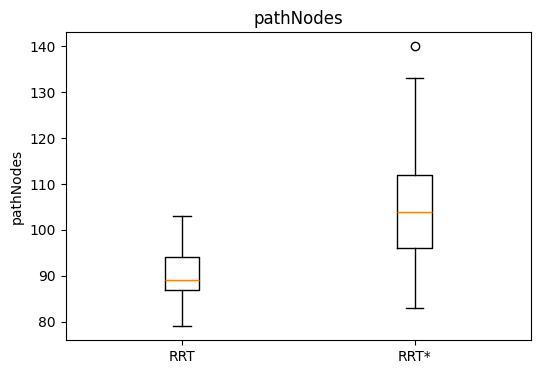


=========== euclideanLength ===========
                   mean   median     std      min      max
algorithmName                                             
RRT            1755.499  1737.88  98.969  1530.62  2020.64
RRT*           1482.422  1479.83  21.447  1448.98  1590.96


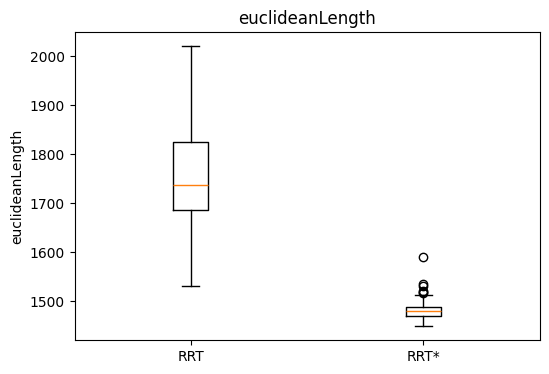


=========== pixelLength ===========
                   mean  median      std   min   max
algorithmName                                       
RRT            1516.376  1493.0  109.988  1269  1809
RRT*           1253.172  1250.0   36.594  1181  1411


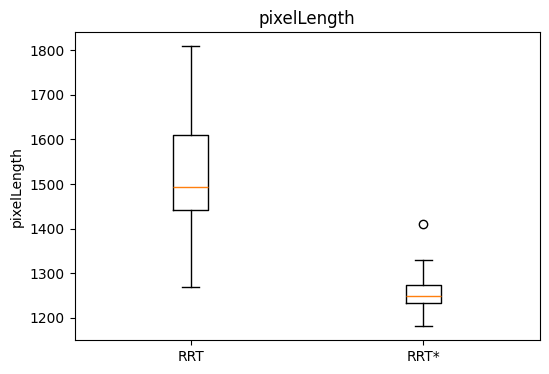


=========== minObstacleDistance ===========
                mean  median    std  min  max
algorithmName                                
RRT            3.720     4.0  0.697    2    4
RRT*           3.677     4.0  0.740    2    4


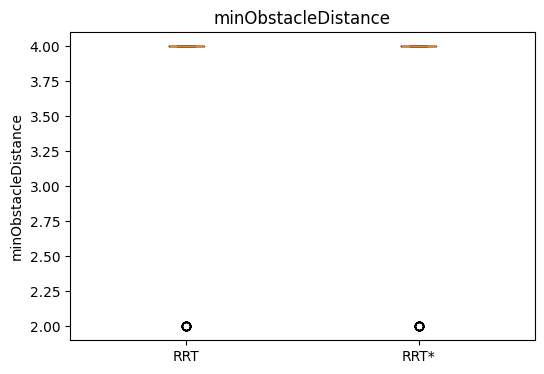


=========== minObstacleDistancePixel ===========
                mean  median    std  min  max
algorithmName                                
RRT            3.720     4.0  0.697    2    4
RRT*           3.677     4.0  0.740    2    4


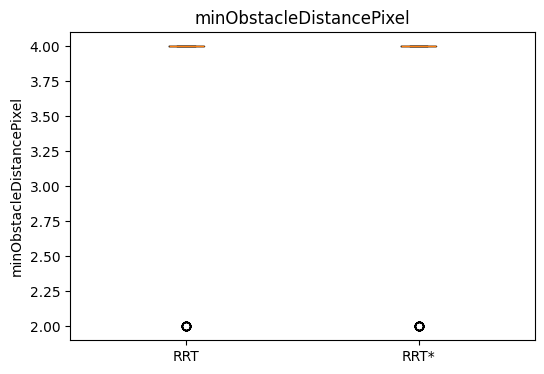


=========== maxSideAngle ===========
                 mean  median    std     min     max
algorithmName                                       
RRT            28.991  29.415  1.040  25.335  29.985
RRT*           28.930  29.389  1.171  23.345  29.969


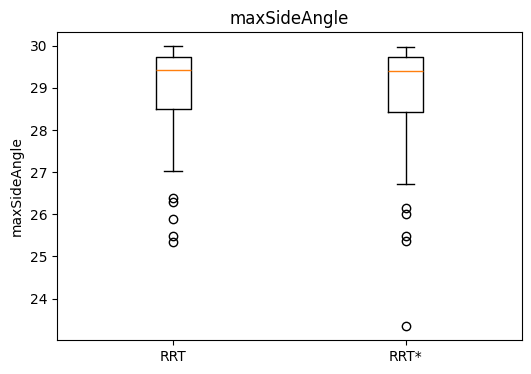


=========== maxUpDownAngle ===========
                 mean  median    std     min     max
algorithmName                                       
RRT            25.824  26.776  3.334  14.654  29.835
RRT*           23.523  24.516  5.052  11.091  29.966


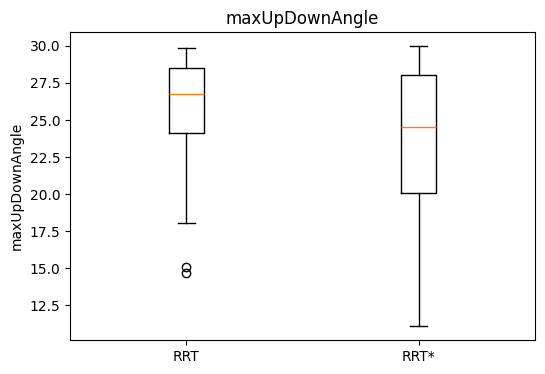

In [8]:
metrics = [
    "executionTimeMs",
    "expandedNodes",
    "pathNodes",
    "euclideanLength",
    "pixelLength",
    "minObstacleDistance",
    "minObstacleDistancePixel",
    "maxSideAngle",
    "maxUpDownAngle"
]

for metric in metrics:
    print(f"\n\033[1m=========== {metric} ===========\033[0m")

    summary = (
        continuous_ok.groupby("algorithmName")[metric]
          .agg(["mean", "median", "std", "min", "max"])
          .round(3)
    )

    print(summary)
    plt.figure(figsize=(6, 4))

    plt.boxplot([
        rrt[metric],
        rrt_star[metric]
    ], tick_labels=["RRT", "RRT*"])

    plt.title(metric)
    plt.ylabel(metric)

    plt.show()

#### Вывод

Оба алгоритма во всех проведённых испытаниях успешно находили путь. При этом RRT выполнялся значительно быстрее, однако получаемые маршруты были менее оптимальными. RRT* строил более короткие и качественные пути за счёт процедуры переподключения вершин, но требовал существенно большего времени вычислений и обрабатывал значительно большее число узлов. При этом расстояние до препятствий и ограничения по углам движения у обоих алгоритмов оказались сопоставимыми.

#### RRT* vs RRT

Подготовка метрик


=== time_ratio ===
mean      0.047
median    0.009
std       0.178
min       0.002
max       1.610
Name: time_ratio, dtype: float64


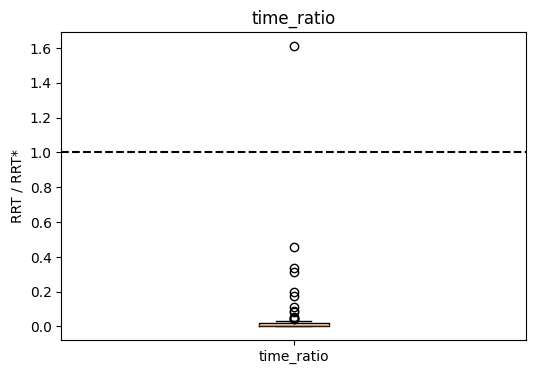


=== expandedNodes_ratio ===
mean      0.061
median    0.032
std       0.098
min       0.007
max       0.720
Name: expandedNodes_ratio, dtype: float64


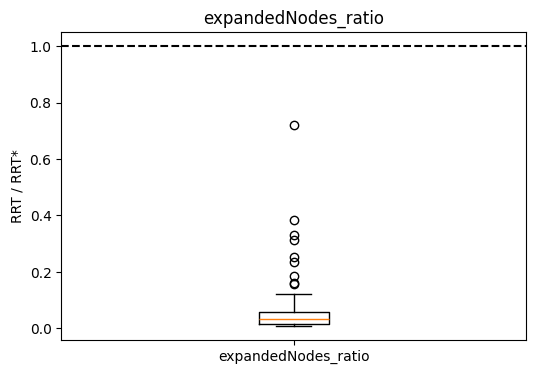


=== path_nodes_ratio ===
mean      0.872
median    0.863
std       0.104
min       0.671
max       1.105
Name: path_nodes_ratio, dtype: float64


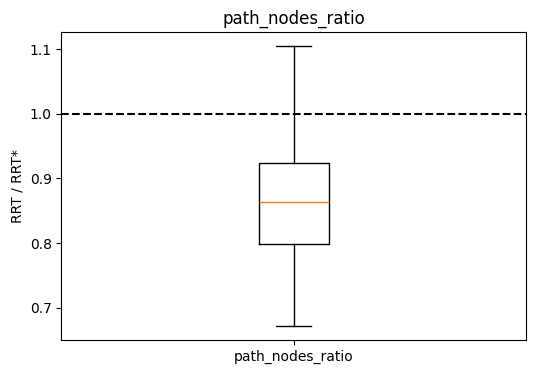


=== euclid_ratio ===
mean      1.184
median    1.173
std       0.065
min       1.048
max       1.336
Name: euclid_ratio, dtype: float64


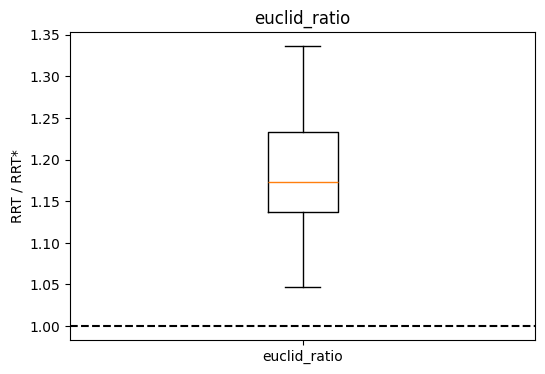


=== pixel_ratio ===
mean      1.211
median    1.196
std       0.090
min       1.009
max       1.400
Name: pixel_ratio, dtype: float64


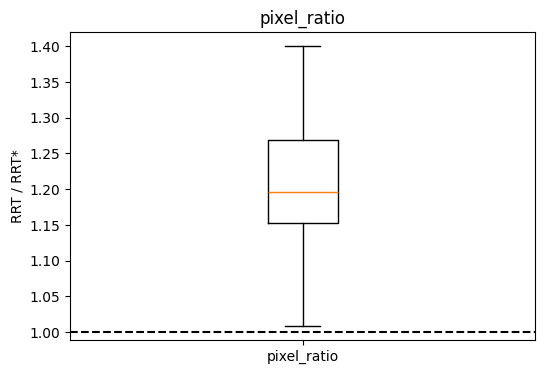

In [9]:
ratios = {
    "time_ratio": rrt["executionTimeMs"].to_numpy() / rrt_star["executionTimeMs"].to_numpy(),
    "expandedNodes_ratio": rrt["expandedNodes"].to_numpy() / rrt_star["expandedNodes"].to_numpy(),
    "path_nodes_ratio": rrt["pathNodes"].to_numpy() / rrt_star["pathNodes"].to_numpy(),
    "euclid_ratio": rrt["euclideanLength"].to_numpy() / rrt_star["euclideanLength"].to_numpy(),
    "pixel_ratio": rrt["pixelLength"].to_numpy() / rrt_star["pixelLength"].to_numpy(),
}

ratio_df = pd.DataFrame(ratios)

for name in ratio_df.columns:
    print(f"\n\033[1m=== {name} ===\033[0m")

    summary = ratio_df[name].agg(["mean", "median", "std", "min", "max"]).round(3)
    print(summary)

    plt.figure(figsize=(6, 4))

    plt.boxplot([ratio_df[name]], tick_labels=[name])
    plt.axhline(1.0, linestyle="--", color="black")

    plt.title(name)
    plt.ylabel("RRT / RRT*")

    plt.show()

#### Вывод

По результатам экспериментов RRT в среднем работал примерно в 20 раз быстрее, чем реализованная версия RRT*. При этом RRT* исследовал приблизительно в 16 раз больше вершин, однако благодаря этому строил пути лучшего качества: среднее число вершин в маршруте увеличилось примерно на 10%, евклидова длина пути — примерно на 18%, а фактическая длина пути по пикселям — примерно на 21%. Таким образом, RRT демонстрирует значительно более высокую скорость построения пути, тогда как RRT* достигает более высокого качества маршрута ценой существенно больших вычислительных затрат.